<a href="https://colab.research.google.com/github/vasudev006/PDE-Transform-S3/blob/main/LAB_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Experiment 6: The Inverse Laplace Transform**
After analyzing a system or signal in the frequency domain, we often need to return to the time domain to understand the actual physical behavior—how voltage changes, how a robot arm moves, etc. The **Inverse Laplace Transform**, denoted $\mathcal{L}^{-1}\{F(s)\}$
, accomplishes this, converting a function $F(s)$
 back into its time-domain equivalent, $f(t)$
.

##Aim
To compute the Inverse Laplace transform of given s-domain functions and to visualize the connection between the frequency-domain characteristics and the resulting time-domain signal.

##Objectives
* To use `SymPy` to calculate the inverse Laplace transform of a given function $F(s)$
.
* To analyze the frequency response (magnitude and phase) of the given $F(s)$
.
* To plot the resulting time-domain function $f(t)$
.
* To visually connect features in the frequency domain (like resonant peaks) to behaviors in the time domain (like oscillations).

##Algorithm
1.**Import Libraries**: Import sympy, numpy, and matplotlib.pyplot.

2.**Define Symbols**: Declare symbolic variables s, t, and w.

3.**Define Laplace-Domain Function:** Specify the s-domain function
 as a symbolic expression.

4.**Analyze Frequency Response of F(s):**
* Substitute
 to get the frequency response function
.
* Lambdify
 to prepare for numerical plotting.
* Generate a frequency array w_values and calculate the magnitude and phase of
.

5.**Compute the Inverse Laplace Transform:**
* Use sp.inverse_laplace_transform(F, s, t)[0] to find the time-domain function
.
* Lambdify the resulting symbolic expression
.

6.**Plot and Visualize:** Create a set of plots to show the full picture:
* The Magnitude plot of $F(j\omega)$
.
* The Phase plot of $F(j\omega)$
.
* The resulting time-domain plot of $f(t)$
.

##Case Study: An Ideal Resonator
**Problem:** You are given the s-domain function $F(s) = \frac{1}{s^2 + 1}$
 . This is the transfer function of an ideal, undamped second-order system (like a frictionless mass-spring or a lossless LC circuit). Analyze its frequency response and find its impulse response in the time domain by computing the inverse Laplace transform.

**Theoretical Result:** This is the classic transform pair for $\sin(t)$
.

The given F(s) is: 1/(s**2 + 1)
The computed Inverse Laplace Transform f(t) is: sin(t)


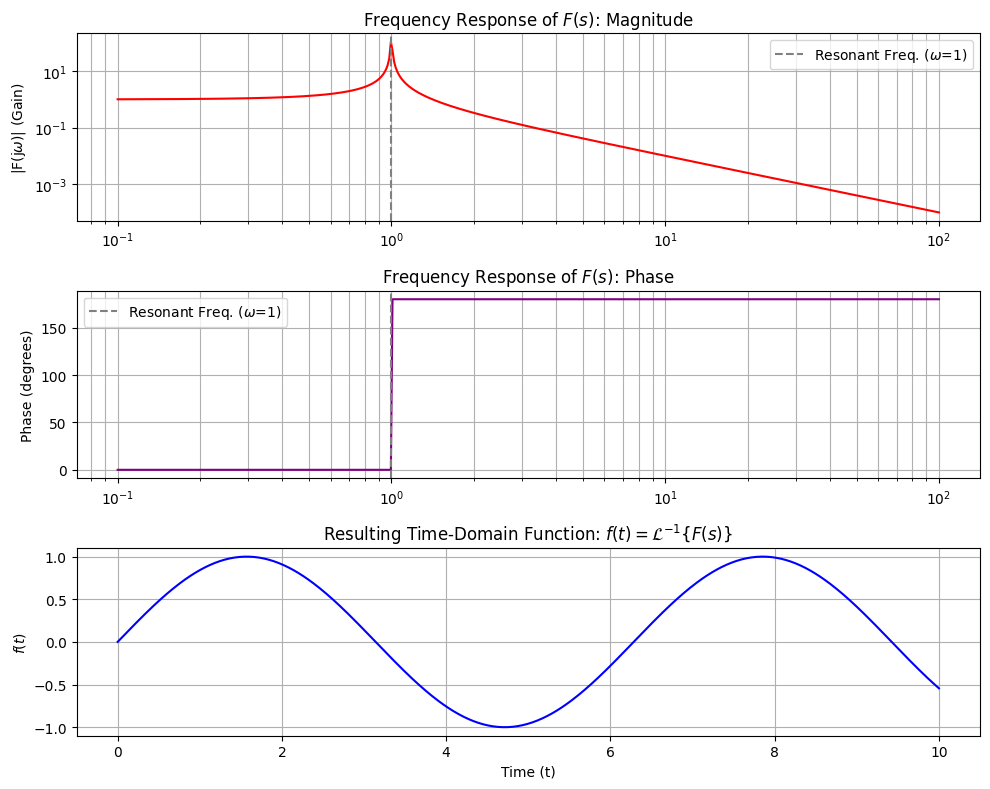

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# --- 1. & 2. Define symbols ---
s, t, w = sp.symbols('s t w', real=True, positive=True)

# --- 3. Define Laplace-domain function ---
F_s = 1 / (s**2 + 1)

# --- 4. Analyze Frequency Response of F(s) ---
F_jw = F_s.subs(s, 1j * w)
F_jw_func = sp.lambdify(w, F_jw, 'numpy')

w_values = np.logspace(-1, 2, 500)
F_jw_values = F_jw_func(w_values)
magnitude = np.abs(F_jw_values)
phase = np.angle(F_jw_values, deg=True)

# --- 5. Compute Inverse Laplace Transform ---
f_t = sp.inverse_laplace_transform(F_s, s, t, noconds=True)
f_t_func = sp.lambdify(t, f_t, 'numpy')

print(f"The given F(s) is: {F_s}")
print(f"The computed Inverse Laplace Transform f(t) is: {f_t}")

# --- 6. Plotting ---
t_values = np.linspace(0, 10, 500)

plt.figure(figsize=(10, 8))

# Plot Magnitude
plt.subplot(3, 1, 1)
plt.loglog(w_values, magnitude, color='red')
plt.title(r'Frequency Response of $F(s)$: Magnitude')
plt.ylabel(r'|F(j$\omega$)| (Gain)')
plt.axvline(x=1, color='gray', linestyle='--', label=r'Resonant Freq. ($\omega$=1)')
plt.grid(True, which="both", ls="-")
plt.legend()

# Plot Phase
plt.subplot(3, 1, 2)
plt.semilogx(w_values, phase, color='purple')
plt.title(r'Frequency Response of $F(s)$: Phase')
plt.ylabel(r'Phase (degrees)')
plt.axvline(x=1, color='gray', linestyle='--', label=r'Resonant Freq. ($\omega$=1)')
plt.grid(True, which="both", ls="-")
plt.legend()

# Plot Time-domain response f(t)
plt.subplot(3, 1, 3)
plt.plot(t_values, f_t_func(t_values), color='blue')
plt.title(r'Resulting Time-Domain Function: $f(t) = \mathcal{L}^{-1}\{F(s)\}$')
plt.xlabel(r'Time (t)')
plt.ylabel(r'$f(t)$')
plt.grid(True)

plt.tight_layout()
plt.show()

###Results and Discussion
This example provides a perfect illustration of the connection between the frequency and time domains.

* Frequency Domain Analysis: The magnitude plot shows an infinitely sharp resonant peak at $\omega=1$
 rad/s. This tells us the system is extremely sensitive to inputs at this specific frequency and will have a massive response. The phase plot shows an instantaneous 180-degree flip at $\omega=1$
, another hallmark of ideal resonance.
* Time Domain Result: The inverse Laplace transform correctly yields $f(t)=sin(t)$
. The plot of this function is an undamped sine wave that oscillates forever. This is the time-domain manifestation of the infinite resonant peak seen in the frequency domain. An undamped system, when “hit” by an impulse, will oscillate at its natural frequency indefinitely.

##Application Challenge: Step Response of an RLC Circuit
Problem: Consider a series RLC circuit which is initially at rest (zero initial conditions). A step voltage of 5 volts is applied at $t=0$
. Determine the step response of the circuit, i.e., the current $i(t)$
 as a function of time, using the inverse Laplace transform method. Use the following component values:

* Resistance (R): 10 Ω
* Inductance (L): 0.1 H
* Capacitance (C): 0.001 F (1 mF)

Circuit Analysis

For a series RLC circuit, Kirchhoff’s Voltage Law (KVL) gives:

 $$L \frac{di(t)}{dt} + R i(t) + \frac{1}{C} \int_0^t i(\tau) \, d\tau = v_s(t)$$


Taking the Laplace transform of the entire equation (with zero initial conditions):

 $$sLI(s) + RI(s) + \frac{1}{sC}I(s) = V(s)$$



The input is a step voltage of 5V, so $v_s(t) = 5u(t)$
, and its transform is $V(s) = \frac{5}{s}$
. Substituting for $V(s)$
 and solving for the current $I(s)$
:


 $$I(s) \left( sL + R + \frac{1}{sC} \right) = \frac{5}{s} \implies I(s) = \frac{\frac{5}{s}}{sL + R + \frac{1}{sC}}$$




Simplifying this expression gives us the function we need to find the inverse transform of:

$$I(s) = \frac{5/L}{s^2 + \frac{R}{L}s + \frac{1}{LC}}$$



The s-domain expression for the current is I(s) =
         50.0         
──────────────────────
 2                    
s  + 100.0⋅s + 10000.0

The time-domain expression for the current is i(t) =
                   -50.0⋅t                        
0.577350269189626⋅ℯ       ⋅sin(86.6025403784439⋅t)


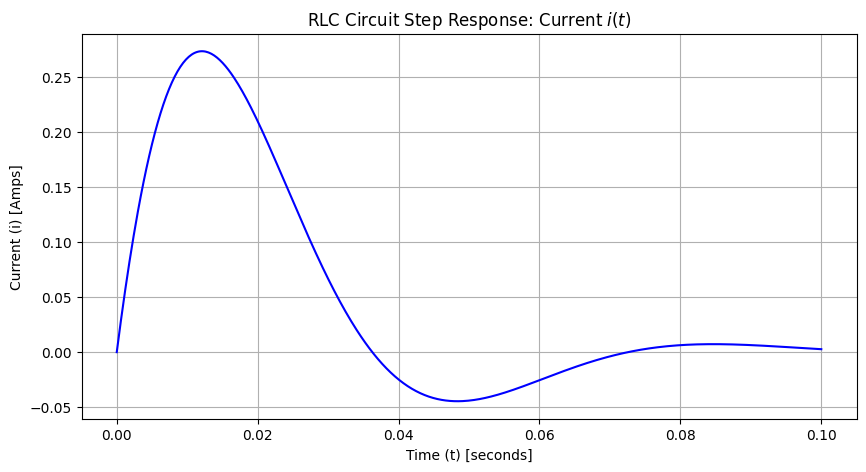

In [2]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# --- Define symbols and parameters ---
s, t = sp.symbols('s t', real=True, positive=True)
R_val, L_val, C_val, V_val = 10, 0.1, 0.001, 5

# --- Define the s-domain function I(s) ---
# Derived from the circuit analysis above
I_s = (V_val / L_val) / (s**2 + (R_val / L_val) * s + 1 / (L_val * C_val))
print(f"The s-domain expression for the current is I(s) =")
sp.pprint(I_s)

# --- Compute the Inverse Laplace Transform to find i(t) ---
# <<<<<<<<<<<<<<<<<<<< FIX IS HERE: Add noconds=True <<<<<<<<<<<<<<<<<<<<
i_t = sp.inverse_laplace_transform(I_s, s, t, noconds=True)
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
print("\nThe time-domain expression for the current is i(t) =")
sp.pprint(i_t)

# --- Lambdify for plotting ---
i_t_func = sp.lambdify(t, i_t, 'numpy')

# --- Generate time values and plot ---
t_values = np.linspace(0, 0.1, 500) # The action happens quickly
i_values = i_t_func(t_values)

plt.figure(figsize=(10, 5))
plt.plot(t_values, i_values, color='blue')
plt.title(r'RLC Circuit Step Response: Current $i(t)$')
plt.xlabel(r'Time (t) [seconds]')
plt.ylabel(r'Current (i) [Amps]')
plt.grid(True)
plt.show()

##Discussion of RLC Circuit Result
The inverse Laplace transform provides the exact analytical solution for the current $i(t)$
 in the circuit.

* Underdamped Response: The plot shows a classic underdamped response. When the voltage is applied, the current surges to a peak, overshoots the final steady-state value, and then oscillates with decreasing amplitude until it settles.

* Steady-State Behavior: As $t\to \infty$
, the current $i(t)\to 0$. This is physically correct. In a DC circuit, after the initial transient period, the inductor acts like a short circuit (a wire) and the capacitor acts as an open circuit. Since the capacitor blocks the DC current in the steady state, the final current must be zero.

* Connection to System Poles: The oscillatory behavior is due to the complex conjugate poles of the denominator of $I(s)$
. If the poles were real and distinct, the response would be overdamped (no oscillation). If the poles were real and repeated, it would be critically damped. This problem beautifully demonstrates how the mathematical properties of $F(s)$
 directly dictate the physical nature of $f(t)$
.